# 0. Project Overview and Machine Learning Pipeline (Workflow)

This project aims to predict the outcome of shots taken by Kobe Bryant (target variable `shot_made_flag`) based on historical, spatial, and contextual data. 

To ensure methodological rigor and the scientific validity of the results, the project is structured as an end-to-end Machine Learning pipeline, with a strong emphasis on **preventing data leakage** and maximizing model **interpretability**.

The logical workflow is divided into **4 main macro-phases**:

### Phase 1: Data Ingestion & Leakage Prevention (Step 1)
The absolute priority of this phase is to preserve the integrity of the experiment. Before any statistical exploration or manipulation, the dataset is cleaned of missing target values and immediately split into **Training, Validation, and Test sets**. All subsequent analysis (EDA), calculations, and transformations are "fitted" **exclusively on the training data**, making the approach robust and simulating a real-world production environment.

### Phase 2: Exploratory Data Analysis & Feature Engineering (Steps 2 - 8)
Extracting value from raw data occurs in two main directions:
* **Visual and Spatial Exploration:** Analysis of class balance and geometric mapping of shot attempts (Shot Map) to identify the player's spatial tendencies and comfort zones.
* **Enrichment and Transformation:** Creation of new contextual and psychological variables (e.g., *clutch time*, distances, angles). To handle categorical text features without the extreme dimensional expansion of One-Hot Encoding, a rigorous **Target Encoding** technique is implemented. A subsequent correlation matrix validates the feature engineering choices and solves multicollinearity between some features.

### Phase 3: Modeling and Optimization (Steps 9 - 12)
The predictive phase is structured incrementally:
1. **Baseline Model:** Training a Random Forest classifier with default parameters to establish a minimum performance threshold (Accuracy and ROC AUC).
2. **Hyperparameter Tuning:** Utilizing `RandomizedSearchCV` to optimize the Random Forest, maximizing predictive power while preventing overfitting.
3. **Advanced Modeling:** Introduction and tuning of a Gradient Boosting framework (**XGBoost**) for a direct head-to-head comparison, testing the inherent "ceiling of predictability" in sports analytics.

### Phase 4: Interpretability and Final Evaluation (Steps 11 - 13)
Beyond overall accuracy, this project seeks to understand *how* the model makes its decisions.
* **Feature Importance:** Extracting feature weights to quantify the influence of shot biomechanics and court geometry versus temporal pressure (time remaining).
* **Unseen Data Evaluation:** Final evaluation of the winning model (Random Forest) on the Test Set, accompanied by a **qualitative error analysis**. This concluding step proves the model's generalization capabilities, analyzing the discrepancy between Precision and Recall, and contextualizing prediction errors within the real-world tactical difficulties of basketball (e.g., the high unpredictability of *mid-range* shots).

# 1. Data Loading and Splitting

Before proceeding with the analysis, we need to initialize our Python environment and load the dataset. As a first fundamental step, we remove any records where the target variable (`shot_made_flag`) is missing. 

To strictly prevent any risk of **data leakage** and respect the temporal nature of sports data, we first sort the records chronologically by game date. We then perform a **chronological data split** (disabling random shuffling), dividing the dataset into **Training (70%)**, **Validation (15%)**, and **Test (15%)** sets. This time-series approach ensures the model learns exclusively from past games to predict future ones, avoiding "time leakage" and simulating a realistic real-world scenario. All subsequent exploration (EDA) and preprocessing steps will be fitted exclusively on the training data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Set graphical theme for future plots
sns.set_theme(style="whitegrid")

# Dataset loading
df_full = pd.read_csv('data.csv')

# Drop missing target values
df_clean = df_full.dropna(subset=['shot_made_flag']).copy()

# Convert game_date to datetime format and sort chronologically
# This is a critical step to ensure the integrity of our time-series-like evaluation
df_clean['game_date'] = pd.to_datetime(df_clean['game_date'])
df_clean = df_clean.sort_values(by='game_date').reset_index(drop=True)

X = df_clean.drop(columns=['shot_made_flag'])
y = df_clean['shot_made_flag']

# Chronological split into Training (70%), Validation (15%), and Test (15%) sets.
# We set shuffle=False to strictly respect the temporal order and prevent time leakage.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, shuffle=False)

# Display the shape of the resulting datasets
print("--- Post-Split Dimensions ---")
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}\n")

# Verify chronological integrity
print("--- Chronological Split Verification ---")
print(f"Training set  : from {X_train['game_date'].min().date()} to {X_train['game_date'].max().date()}")
print(f"Validation set: from {X_val['game_date'].min().date()} to {X_val['game_date'].max().date()}")
print(f"Test set      : from {X_test['game_date'].min().date()} to {X_test['game_date'].max().date()}\n")

print("--- Features (X_train) ---")
X_train.info()

--- Post-Split Dimensions ---
Training set shape: (17987, 24)
Validation set shape: (3855, 24)
Test set shape: (3855, 24)

--- Chronological Split Verification ---
Training set  : from 1996-11-03 to 2009-06-04
Validation set: from 2009-06-04 to 2012-02-03
Test set      : from 2012-02-03 to 2016-04-13

--- Features (X_train) ---
<class 'pandas.core.frame.DataFrame'>
Index: 17987 entries, 0 to 17986
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   action_type         17987 non-null  object        
 1   combined_shot_type  17987 non-null  object        
 2   game_event_id       17987 non-null  int64         
 3   game_id             17987 non-null  int64         
 4   lat                 17987 non-null  float64       
 5   loc_x               17987 non-null  int64         
 6   loc_y               17987 non-null  int64         
 7   lon                 17987 non-null  float64       
 8   m

# 2. Exploratory Data Analysis (EDA) - Shot distribution

### Target Variable Distribution: Class Imbalance Check

The first step in our exploratory analysis is to examine the distribution of our target variable, `shot_made_flag`. By visualizing the ratio of missed to made shots strictly within the training set, we can determine if the dataset is well-balanced or if we need to address potential class imbalance during the modeling phase.

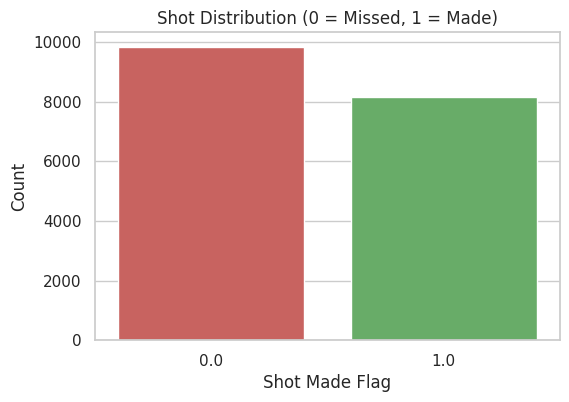

--- Kobe Bryant Shot Statistics (Training Set) ---
Total Shots Analyzed: 17,987
Missed Shots (0):     54.67%
Made Shots (1):       45.33%
--------------------------------------------------


In [2]:
# Temporarily merge X_train and y_train into a single dataframe for plotting
train_data = X_train.copy()
train_data['shot_made_flag'] = y_train

# Plot the distribution of made vs missed shots (Class Imbalance check)
plt.figure(figsize=(6, 4))
color_dict = {0: '#d9534f', 1: '#5cb85c'}
# FIX: Added 'hue' and 'legend=False' to avoid Seaborn FutureWarning
sns.countplot(data=train_data, x='shot_made_flag', hue='shot_made_flag', palette=color_dict, legend=False)
plt.title("Shot Distribution (0 = Missed, 1 = Made)")
plt.xlabel("Shot Made Flag")
plt.ylabel("Count")
plt.show()

# Calculate and print formatted percentages
percentages = train_data['shot_made_flag'].value_counts(normalize=True) * 100
missed_pct = percentages[0]
made_pct = percentages[1]

print("--- Kobe Bryant Shot Statistics (Training Set) ---")
print(f"Total Shots Analyzed: {len(train_data):,}")
print(f"Missed Shots (0):     {missed_pct:.2f}%")
print(f"Made Shots (1):       {made_pct:.2f}%")
print("-" * 50)

# 3. Exploratory Data Analysis (EDA) - Spatial Shot Map

### Spatial Analysis: Shot Map

To better understand the geometric context of the dataset, we visualize the spatial distribution of the shot attempts. By plotting the `loc_x` and `loc_y` coordinates on a custom-drawn NBA half-court, we can visually inspect Kobe Bryant's tendencies, "comfort zones" and how the shot location correlates with its success rate.

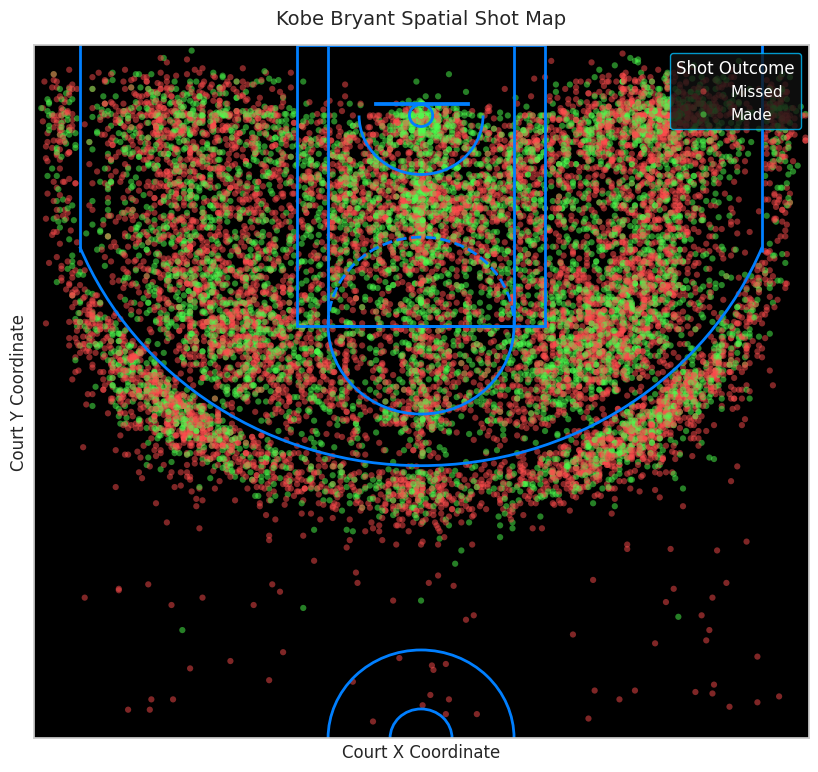

In [3]:
from matplotlib.patches import Circle, Rectangle, Arc

# Function to draw the basketball court lines
def draw_court(ax=None, color='black', lw=2):
    """
    Draws a half NBA basketball court using matplotlib patches.
    Coordinates are scaled to match the Kaggle Kobe Bryant dataset.
    """
    if ax is None:
        ax = plt.gca()

    # 1. Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # 2. Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # 3. The paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)

    # 4. Free Throw Line and Arcs
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')

    # 5. Restricted Zone
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)

    # 6. 3-Point Line
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)

    # 7. Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0, linewidth=lw, color=color)

    # List of all court elements
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc, center_inner_arc]

    # Add the elements to the axes
    for element in court_elements:
        ax.add_patch(element)

    return ax

# --- Plotting the Map ---
fig, ax = plt.subplots(figsize=(10, 9))

ax.set_facecolor('black')
color_dict = {0: '#ff4d4d', 1: '#4dff4d'} # 0 = Vivid Red, 1 = Vivid Green
sns.scatterplot(data=train_data, x='loc_x', y='loc_y', hue='shot_made_flag', 
                alpha=0.5, palette=color_dict, s=20, ax=ax, edgecolor='none')

draw_court(ax=ax, color='#007fff', lw=2)

# Set axes limits to focus on the half-court
plt.xlim(-250, 250)
plt.ylim(422.5, -47.5) # Y is inverted to put the hoop at the correct visual location

# Titles and labels 
plt.title("Kobe Bryant Spatial Shot Map", fontsize=14, pad=15)
plt.xlabel("Court X Coordinate")
plt.ylabel("Court Y Coordinate")

# Legend
handles, previous_labels = ax.get_legend_handles_labels()
leg = plt.legend(handles=handles, labels=['Missed', 'Made'], title='Shot Outcome', loc='upper right')

leg.get_frame().set_facecolor('#111111')
leg.get_frame().set_edgecolor('#00bfff') 
for text in leg.get_texts():
    text.set_color("white")
leg.get_title().set_color("white")

plt.xticks([])
plt.yticks([])

plt.show()

# 4. Missing Value Verification

In [4]:
# Verify that the dataset does not contain missing values
print(f"Total missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Total missing values in X_val:   {X_val.isnull().sum().sum()}")
print(f"Total missing values in X_test:  {X_test.isnull().sum().sum()}")

Total missing values in X_train: 0
Total missing values in X_val:   0
Total missing values in X_test:  0


Since all data splits (Train, Validation, and Test sets) return exactly 0 missing values, the dataset is completely clean. No missing value imputation or further data cleaning handling is required before training the models.

Raw data often needs transformation to expose the underlying patterns to Machine Learning algorithms more effectively. In this step, we extract new contextual, psychological, and geometric variables, such as "clutch time" scenarios, buzzer-beaters, shot angles, and home-court advantage. 

We also drop constant or redundant columns to reduce dimensionality. To maintain strict data integrity, this custom engineering function is applied consistently across the Training, Validation, and Test sets.

# 5. Feature Engineering

In [5]:
def engineer_features(df):
    """
    Applies advanced feature engineering to the Kobe Bryant dataset.
    Creates variables for clutch moments, geometry, and seasonality.
    """
    df_new = df.copy()
    
    # --- 1. TIME & PSYCHOLOGICAL FEATURES ---
    if 'minutes_remaining' in df_new.columns and 'seconds_remaining' in df_new.columns:
        # Total seconds remaining
        df_new['time_remaining_seconds'] = df_new['minutes_remaining'] * 60 + df_new['seconds_remaining']
        
        if 'period' in df_new.columns:
            # Clutch Time: Last 5 minutes of the 4th quarter or Overtime (period >= 4)
            is_clutch = (df_new['period'] >= 4) & (df_new['minutes_remaining'] < 5)
            df_new['is_clutch_time'] = is_clutch.astype(int)
        
        # Buzzer Beaters: Last 3 seconds of any period
        is_buzzer = (df_new['minutes_remaining'] == 0) & (df_new['seconds_remaining'] <= 3)
        df_new['is_buzzer_beater'] = is_buzzer.astype(int)
    
    # --- 2. HOME COURT ADVANTAGE ---
    if 'matchup' in df_new.columns:
        # 'vs.' indicates a home game, '@' indicates an away game
        df_new['is_home'] = df_new['matchup'].apply(lambda x: 1 if isinstance(x, str) and 'vs.' in x else 0)
        
    # --- 3. SPATIAL GEOMETRY ---
    if 'loc_x' in df_new.columns and 'loc_y' in df_new.columns:
        # Calculate the angle of the shot from the hoop using arctangent
        # We add 0.1 to loc_y to avoid division by zero for shots right under the basket
        df_new['shot_angle'] = np.arctan2(df_new['loc_x'], df_new['loc_y'] + 0.1)
        
    # --- 4. SEASONALITY & FATIGUE ---
    if 'game_date' in df_new.columns:
        # Convert string to datetime objects
        df_new['game_date'] = pd.to_datetime(df_new['game_date'])
        # Extract month (season phase) and year (career progression)
        df_new['game_month'] = df_new['game_date'].dt.month
        df_new['game_year'] = df_new['game_date'].dt.year

    # --- 5. CLEANUP ---
    # Drop variables that are redundant, transformed, or non-predictive
    cols_to_drop = [
        'minutes_remaining', 'seconds_remaining', 
        'matchup', 'game_id', 'game_event_id', 'game_date', 
        'lat', 'lon',               # Redundant with loc_x and loc_y
        'team_id', 'team_name'      # Constant columns (always Lakers)
    ]
    df_new = df_new.drop(columns=cols_to_drop, errors='ignore')
    
    return df_new

# Apply the feature engineering function to all three splits
print(f"Original X_train shape: {X_train.shape}")

X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

print(f"New X_train shape: {X_train.shape}")
print("Advanced features successfully created!")
print("--- Features (X_train) ---")
print(X_train.info())

Original X_train shape: (17987, 24)
New X_train shape: (17987, 21)
Advanced features successfully created!
--- Features (X_train) ---
<class 'pandas.core.frame.DataFrame'>
Index: 17987 entries, 0 to 17986
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   action_type             17987 non-null  object 
 1   combined_shot_type      17987 non-null  object 
 2   loc_x                   17987 non-null  int64  
 3   loc_y                   17987 non-null  int64  
 4   period                  17987 non-null  int64  
 5   playoffs                17987 non-null  int64  
 6   season                  17987 non-null  object 
 7   shot_distance           17987 non-null  int64  
 8   shot_type               17987 non-null  object 
 9   shot_zone_area          17987 non-null  object 
 10  shot_zone_basic         17987 non-null  object 
 11  shot_zone_range         17987 non-null  object 
 12  opponent       

# 6. Categorical Feature Encoding (Target Encoding)

Machine Learning models require strictly numerical inputs, meaning we must convert our remaining text-based features (such as `action_type`, `opponent`, or `shot_zone`) into numbers. Rather than using standard One-Hot Encoding, which would drastically increase the dimensionality of our dataset, we implement **Target Encoding**. 

This technique replaces each categorical value with its historical probability of success (i.e., the percentage of shots made). Crucially, to strictly prevent data leakage, these probability mappings are learned **exclusively from the Training set** and then applied to the Validation and Test sets. Any unseen categories encountered later are handled robustly by assigning them the global average shot success rate.

In [6]:
# We replace categorical text with the historical probability of success (Target Encoding).
def apply_target_encoding(train_df, val_df, test_df, categorical_cols, target_col_name):
    """
    Applies Target Encoding to a list of categorical columns.
    The probability mapping is learned strictly from train_df.
    """
    df_train = train_df.copy()
    df_val = val_df.copy()
    df_test = test_df.copy()
    
    # We temporarily separate the target variable to calculate means
    y_train_temp = df_train[target_col_name]
    
    for col in categorical_cols:
        # Step 1: Calculate success probability for each category in the Training set
        encoding_map = df_train.groupby(col)[target_col_name].mean().to_dict()
        
        # Step 2: Map the probabilities to Train, Validation, and Test
        df_train[col + '_encoded'] = df_train[col].map(encoding_map)
        df_val[col + '_encoded'] = df_val[col].map(encoding_map)
        df_test[col + '_encoded'] = df_test[col].map(encoding_map)
        
        # Step 3: Handle unseen categories in Validation/Test 
        # (If a new type of shot appears, we assign it the average Kobe Bryant shot percentage)
        global_mean = y_train_temp.mean()
        df_val[col + '_encoded'] = df_val[col + '_encoded'].fillna(global_mean)
        df_test[col + '_encoded'] = df_test[col + '_encoded'].fillna(global_mean)
        
        # Step 4: Drop the original text column
        df_train = df_train.drop(columns=[col])
        df_val = df_val.drop(columns=[col])
        df_test = df_test.drop(columns=[col])
        
    return df_train, df_val, df_test

# Identify remaining text/categorical columns
cat_features_to_encode = [
    'action_type', 'combined_shot_type', 'shot_type', 
    'shot_zone_area', 'shot_zone_basic', 'shot_zone_range',
    'opponent', 'season'
]

# We must ensure the target variable is in X_train just for the calculation
X_train['shot_made_flag'] = y_train

# Apply the target encoding function
X_train, X_val, X_test = apply_target_encoding(X_train, X_val, X_test, cat_features_to_encode, 'shot_made_flag')

# Drop the target variable from X_train again (we only needed it for the math)
X_train = X_train.drop(columns=['shot_made_flag'])

print(f"Final shape of X_train (Numbers only!): {X_train.shape}")
# We can check data types to ensure no 'object' (text) columns remain
print("\nRemaining data types:")
print(X_train.dtypes.value_counts())
print("--- Features (X_train) ---")
print(X_train.info())

Final shape of X_train (Numbers only!): (17987, 21)

Remaining data types:
int64      10
float64     9
int32       2
Name: count, dtype: int64
--- Features (X_train) ---
<class 'pandas.core.frame.DataFrame'>
Index: 17987 entries, 0 to 17986
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loc_x                       17987 non-null  int64  
 1   loc_y                       17987 non-null  int64  
 2   period                      17987 non-null  int64  
 3   playoffs                    17987 non-null  int64  
 4   shot_distance               17987 non-null  int64  
 5   shot_id                     17987 non-null  int64  
 6   time_remaining_seconds      17987 non-null  int64  
 7   is_clutch_time              17987 non-null  int64  
 8   is_buzzer_beater            17987 non-null  int64  
 9   is_home                     17987 non-null  int64  
 10  shot_angle                  17987 non

# 7. Correlation Matrix

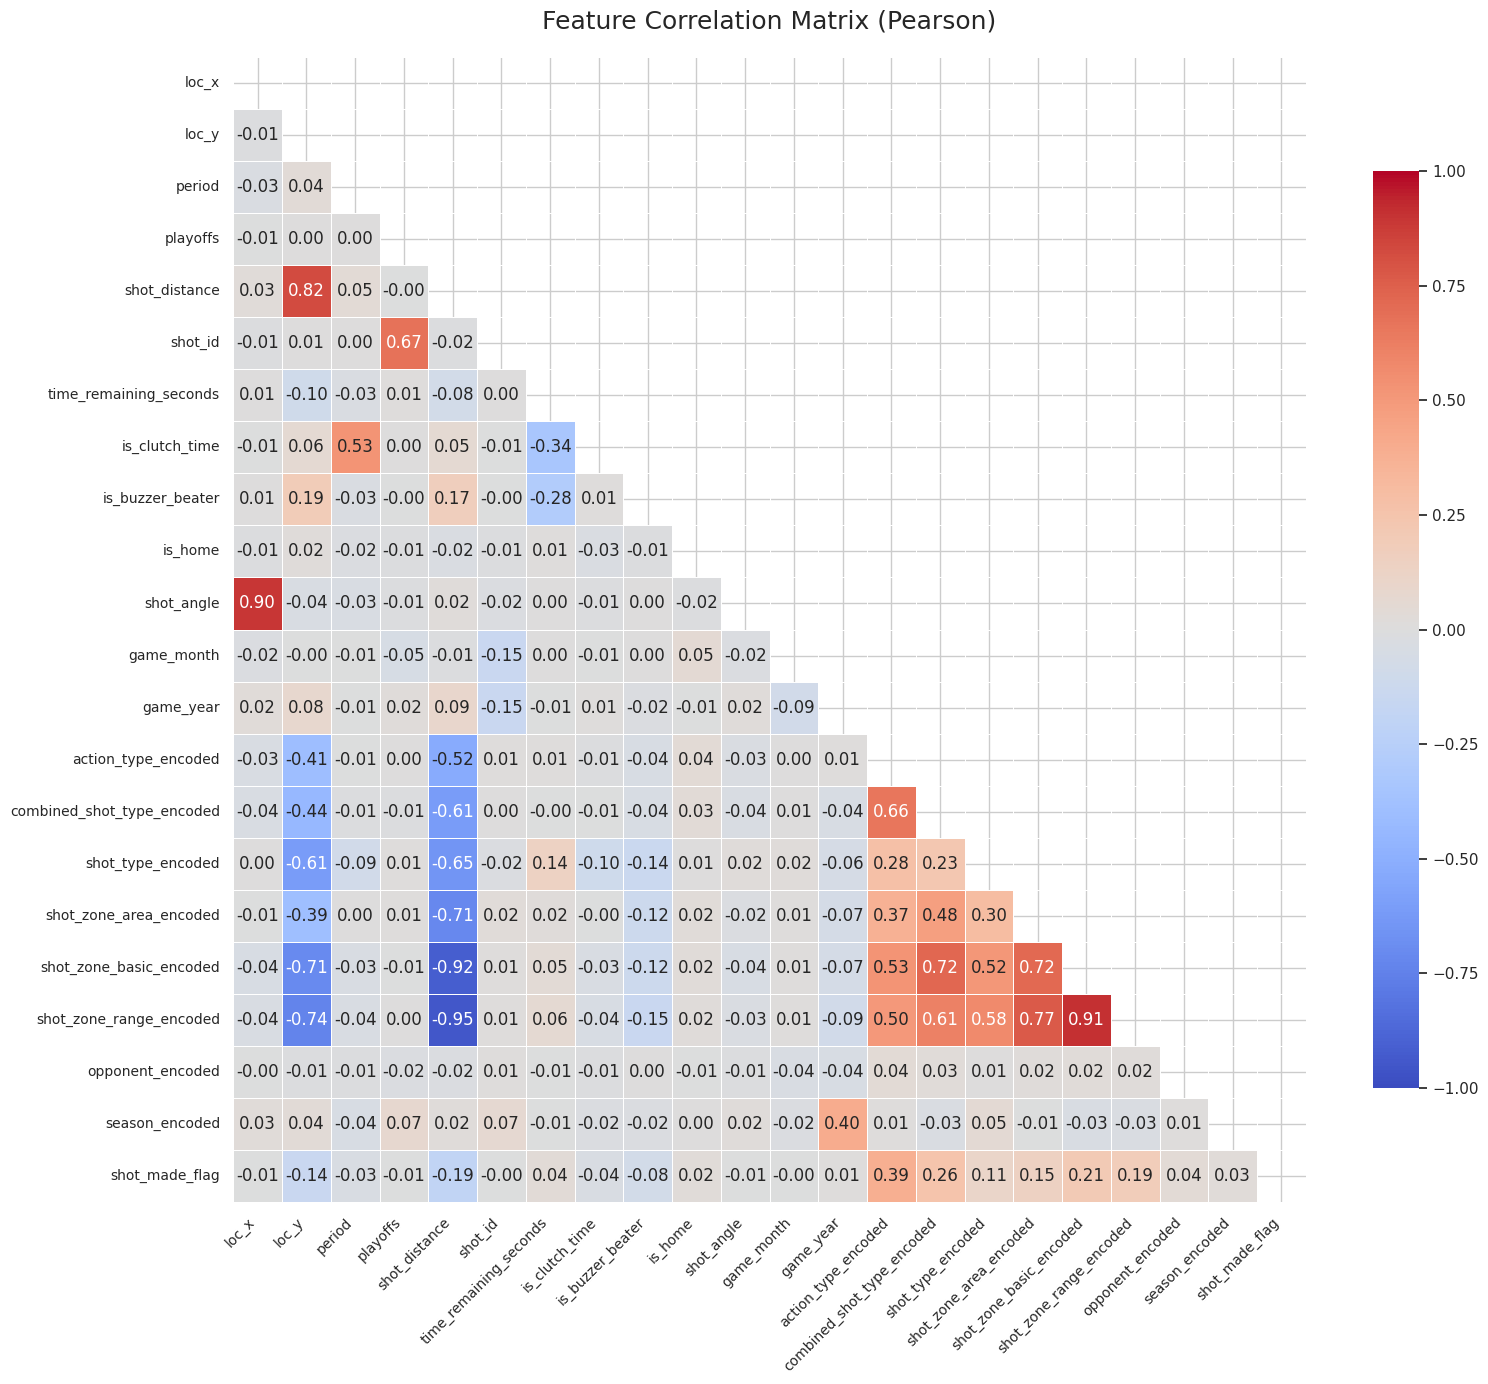


--- HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.80) ---
shot_zone_range_encoded <--> shot_distance: -0.9478
shot_zone_basic_encoded <--> shot_distance: -0.9213
shot_zone_basic_encoded <--> shot_zone_range_encoded: 0.9109
loc_x <--> shot_angle: 0.8961
shot_distance <--> loc_y: 0.8242


In [7]:
# We calculate the Pearson correlation matrix to identify linear relationships 
# between features and check for multicollinearity before modeling.

# 1. Temporarily add the target variable to see its correlation with our features
df_corr = X_train.copy()
df_corr['shot_made_flag'] = y_train

# 2. Calculate the correlation matrix
corr_matrix = df_corr.corr()

# 3. Create a mask to hide the upper triangle (since the matrix is symmetrical)
# This makes the plot much cleaner and more professional
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Set up the matplotlib figure
plt.figure(figsize=(16, 14))

# 5. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm',   # Red = Positive correlation, Blue = Negative correlation
    vmax=1.0, vmin=-1.0, 
    center=0,
    annot=True,        # Show the actual correlation numbers
    fmt=".2f",         # Format numbers to 2 decimal places
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

# 6. Formatting
plt.title("Feature Correlation Matrix (Pearson)", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

# 7. Check and print highly correlated feature pairs to analyze multicollinearity
print("\n--- HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.80) ---")
threshold = 0.80

# Unstack the matrix to get a list of all pairs
corr_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)

# Filter out self-correlations (1.0) and weak correlations
highly_correlated = corr_pairs[(abs(corr_pairs) > threshold) & (corr_pairs < 1.0)]

# Use a set to avoid printing both A<->B and B<->A
printed_pairs = set()
for (feat1, feat2), corr_value in highly_correlated.items():
    # We only care about feature-to-feature correlation, ignore the target variable
    if feat1 != 'shot_made_flag' and feat2 != 'shot_made_flag':
        pair = frozenset([feat1, feat2])
        if pair not in printed_pairs:
            print(f"{feat1} <--> {feat2}: {corr_value:.4f}")
            printed_pairs.add(pair)

if not printed_pairs:
    print(f"No feature pairs found with correlation above {threshold}.")

### Observations from the Correlation Matrix
1. **Validation of Target Encoding:** The correlation matrix confirms the success of our feature engineering. The engineered variables (e.g., `action_type_encoded`, `combined_shot_type_encoded`) show significantly higher positive/negative correlations with the target variable (`shot_made_flag`) compared to the raw numerical features.
2. **Multicollinearity Resolution (Transition to Polar Coordinates):** The matrix reveals severe collinearity within spatial features. Specifically, distance-based zones (`shot_zone_range_encoded`, `shot_zone_basic_encoded`) and the vertical coordinate (`loc_y`) heavily correlate with `shot_distance` (|r| > 0.82). Additionally, the horizontal coordinate (`loc_x`) heavily correlates with `shot_angle` (r = 0.89). To ensure compatibility across all algorithm types (including linear models), we resolve this by dropping the redundant categorical zones and Cartesian coordinates (`loc_x`, `loc_y`). We retain `shot_distance` and `shot_angle`, effectively representing all spatial data through clean, independent Polar coordinates.

# 8. Multicollinearity Resolution

In [8]:
# Dropping highly correlated features to maintain a model-agnostic dataset.
# We retain 'shot_distance' and 'shot_angle' (Polar coordinates) while dropping 
# the redundant Cartesian coordinates and categorical distance zones.

columns_to_drop = [
    'loc_x', 
    'loc_y', 
    'shot_zone_range_encoded', 
    'shot_zone_basic_encoded'
]

X_train = X_train.drop(columns=columns_to_drop)
X_val = X_val.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print(f"Dropped columns to resolve multicollinearity: {columns_to_drop}")
print(f"Remaining features in dataset: {X_train.shape[1]}")
print(X_train.info())

Dropped columns to resolve multicollinearity: ['loc_x', 'loc_y', 'shot_zone_range_encoded', 'shot_zone_basic_encoded']
Remaining features in dataset: 17
<class 'pandas.core.frame.DataFrame'>
Index: 17987 entries, 0 to 17986
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   period                      17987 non-null  int64  
 1   playoffs                    17987 non-null  int64  
 2   shot_distance               17987 non-null  int64  
 3   shot_id                     17987 non-null  int64  
 4   time_remaining_seconds      17987 non-null  int64  
 5   is_clutch_time              17987 non-null  int64  
 6   is_buzzer_beater            17987 non-null  int64  
 7   is_home                     17987 non-null  int64  
 8   shot_angle                  17987 non-null  float64
 9   game_month                  17987 non-null  int32  
 10  game_year                   17987 non-null  int32  
 1

# 9. Baseline Model Training & Evaluation

### Baseline Model: Random Forest Classifier

With the dataset fully preprocessed and encoded, we can now move to the modeling phase. To establish a reliable performance baseline, we first train a **Random Forest Classifier** using its default hyperparameters. 

We fit this algorithm on the Training set and evaluate its predictive power strictly on the **Validation set**. By analyzing metrics such as Accuracy and the ROC AUC score, we set a minimum performance threshold that will guide and justify our subsequent hyperparameter tuning efforts.

In [9]:
# We train a default Random Forest Classifier to establish a performance baseline.
# We evaluate it on the Validation Set to guide future improvements.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# 1. Initialize the Baseline Model
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Train the model on the Training Set
print("Training the Baseline Random Forest Model...")
rf_baseline.fit(X_train, y_train)

# 3. Make predictions on the Validation Set
# predict() gives the hard class (0 or 1)
y_val_pred = rf_baseline.predict(X_val)
# predict_proba() gives the probability (e.g., 80% chance it's a made shot)
y_val_proba = rf_baseline.predict_proba(X_val)[:, 1]

# 4. Evaluate the Performance
accuracy = accuracy_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print("-" * 40)
print("--- BASELINE MODEL PERFORMANCE (VALIDATION SET) ---")
print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"ROC AUC:   {roc_auc:.4f}")
print("-" * 40)

# Print a classification report
print("\nDetailed Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Missed (0)', 'Made (1)']))

Training the Baseline Random Forest Model...
----------------------------------------
--- BASELINE MODEL PERFORMANCE (VALIDATION SET) ---
Accuracy:  0.6719 (67.19%)
ROC AUC:   0.6860
----------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

  Missed (0)       0.67      0.80      0.73      2120
    Made (1)       0.68      0.51      0.59      1735

    accuracy                           0.67      3855
   macro avg       0.67      0.66      0.66      3855
weighted avg       0.67      0.67      0.66      3855



# 10. Hyperparameter Tuning (Random Forest Optimization)

To improve upon our baseline results and prevent potential overfitting, we perform hyperparameter optimization on the Random Forest model. 

Instead of an exhaustive and computationally expensive Grid Search, we utilize **RandomizedSearchCV**. This approach efficiently samples a wide range of parameter combinations (such as tree depth, number of estimators, and minimum samples per leaf) using cross-validation. The goal is to identify the optimal configuration that maximizes our primary evaluation metric, the ROC AUC score. Once the best parameters are found, we evaluate the tuned model on the Validation set to verify the performance gains.

In [10]:
from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Tuning... (This might take a couple of minutes)")

# 1. Define the grid of parameters
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': ['balanced', None]
}

# 2. Initialize the Base Model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Setup the Randomized Search
# NOTE: Setting verbose=0 hides the [CV] END logs
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_distributions, 
    n_iter=20, 
    scoring='roc_auc', 
    cv=3, 
    verbose=0,  
    random_state=42,
    n_jobs=-1
)

# 4. Execute the Search
random_search.fit(X_train, y_train)

# 5. Extract the Best Model
best_rf_model = random_search.best_estimator_

print("\n--- TUNING COMPLETED ---")
print(f"Best Parameters found: {random_search.best_params_}")

# 6. Evaluate the Best Model
y_val_pred_tuned = best_rf_model.predict(X_val)
y_val_proba_tuned = best_rf_model.predict_proba(X_val)[:, 1]

accuracy_tuned = accuracy_score(y_val, y_val_pred_tuned)
roc_auc_tuned = roc_auc_score(y_val, y_val_proba_tuned)

print(f"New Accuracy: {accuracy_tuned:.4f}")
print(f"New ROC AUC:  {roc_auc_tuned:.4f}")

Starting Hyperparameter Tuning... (This might take a couple of minutes)

--- TUNING COMPLETED ---
Best Parameters found: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_depth': 20, 'class_weight': 'balanced'}
New Accuracy: 0.6752
New ROC AUC:  0.6968


# 11. Model Interpretability (Feature Importance)

Understanding how a model makes its decisions is just as crucial as its overall accuracy. We extract the feature importances from our tuned Random Forest to identify which variables most strongly influence the probability of a successful shot.

--- TOP 5 MOST IMPORTANT FEATURES ---
action_type_encoded: 0.3812
shot_distance: 0.0881
time_remaining_seconds: 0.0812
combined_shot_type_encoded: 0.0765
shot_angle: 0.0698


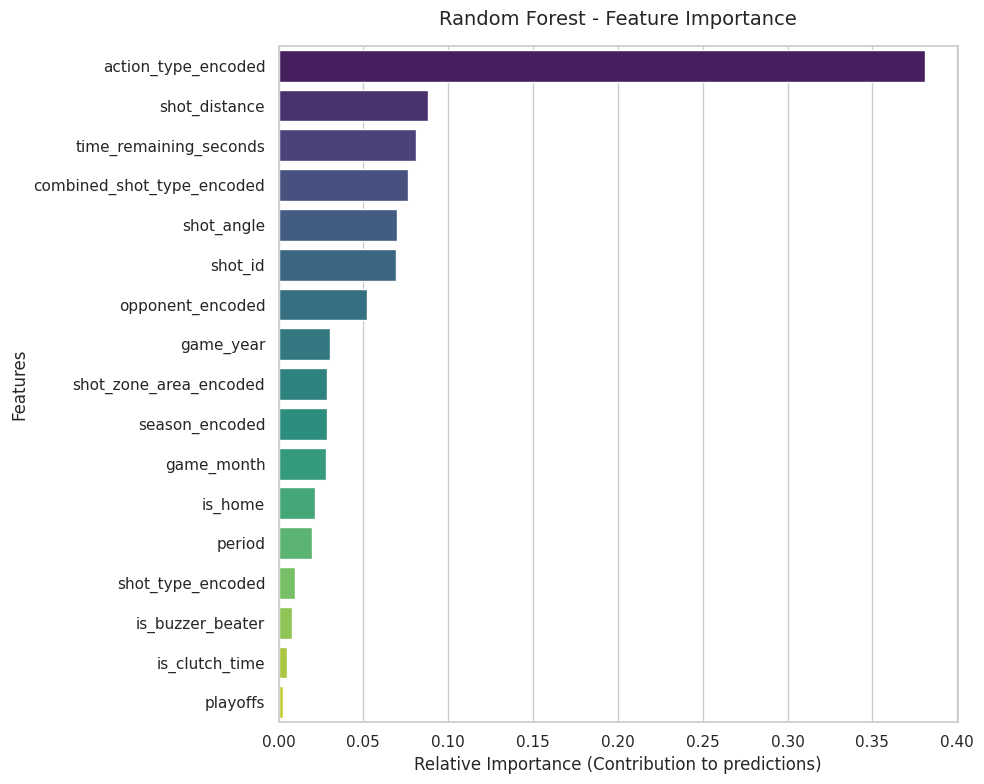

In [11]:
# We extract and visualize the most important variables driving the best Random Forest model's predictions.

# 1. Extract feature importances from the tuned Random Forest model
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for easier sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort values in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot the Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title("Random Forest - Feature Importance", fontsize=14, pad=15)
plt.xlabel("Relative Importance (Contribution to predictions)")
plt.ylabel("Features")
plt.tight_layout()

# 4. Print the top 5 features textually for quick reference
print("--- TOP 5 MOST IMPORTANT FEATURES ---")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

plt.show()

**Insights from Feature Importance:**
The results clearly indicate that the biomechanical execution of the play (`action_type_encoded` and `combined_shot_type_encoded`) dominates the model's decision-making process, jointly accounting for approximately 46% of the predictive weight. 

Spatial geometry (represented by our newly retained polar coordinates) plays a pivotal role, with `shot_distance` emerging as the second most important individual feature, and `shot_angle` rounding out the top five. Finally, temporal pressure (`time_remaining_seconds`) ranks firmly in third place, confirming that the time left on the clock directly impacts shot efficiency.

# 12. XGBoost Model Training & Tuning

To determine if we can push our predictive capabilities even further, we introduce a second model: **eXtreme Gradient Boosting (XGBoost)**. Known for its execution speed and dominance in structured tabular data, this gradient boosting framework often outperforms standard bagging techniques like Random Forest. 

We apply a similar hyperparameter optimization process using `RandomizedSearchCV` to tune specific boosting parameters, such as the learning rate and tree depth, before evaluating its results on the Validation set for a direct head-to-head comparison.

In [12]:
# We implement XGBoost to compete against the Random Forest baseline.

from xgboost import XGBClassifier

print("Starting XGBoost Hyperparameter Tuning... (This might take a moment)")

# 1. Initialize XGBoost
xgb_model = XGBClassifier(objective='binary:logistic', random_state=42, n_jobs=-1, eval_metric='logloss')

# 2. Define the grid of parameters
param_distributions_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 3. Setup Randomized Search
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions_xgb,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=0,  # Silent output
    random_state=42,
    n_jobs=-1
)

# 4. Train the model
xgb_search.fit(X_train, y_train)

# 5. Get best model and evaluate
best_xgb_model = xgb_search.best_estimator_

y_val_pred_xgb = best_xgb_model.predict(X_val)
y_val_proba_xgb = best_xgb_model.predict_proba(X_val)[:, 1]

# Calculate results
accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
roc_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)

print("\n--- XGBOOST MODEL PERFORMANCE (VALIDATION SET) ---")
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"ROC AUC:   {roc_auc_xgb:.4f}")
print("-" * 40)
print(f"Comparison: Random Forest (0.6752) vs XGBoost ({accuracy_xgb:.4f})")

Starting XGBoost Hyperparameter Tuning... (This might take a moment)

--- XGBOOST MODEL PERFORMANCE (VALIDATION SET) ---
Accuracy:  0.6750
ROC AUC:   0.6970
----------------------------------------
Comparison: Random Forest (0.6752) vs XGBoost (0.6750)


Interestingly, the tuned XGBoost model performs very similarly to our Random Forest, slightly underperforming in raw accuracy (67.52% vs 67.50%). 

This performance plateau is common in sports analytics: the inherent physical randomness of a basketball shot means there is a "ceiling" to how well any algorithm can predict the exact outcome. Since the **Random Forest** achieved slightly better accuracy and is generally very robust against overfitting, we will select it as our final, winning model to be evaluated on the unseen Test set.

# 13. Final Evaluation

--- FINAL EVALUATION ON TEST SET ---
Final Test Accuracy: 0.6744
Final Test ROC AUC:  0.6989

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

  Missed (0)       0.71      0.77      0.74      2278
    Made (1)       0.62      0.54      0.58      1577

    accuracy                           0.67      3855
   macro avg       0.66      0.65      0.66      3855
weighted avg       0.67      0.67      0.67      3855



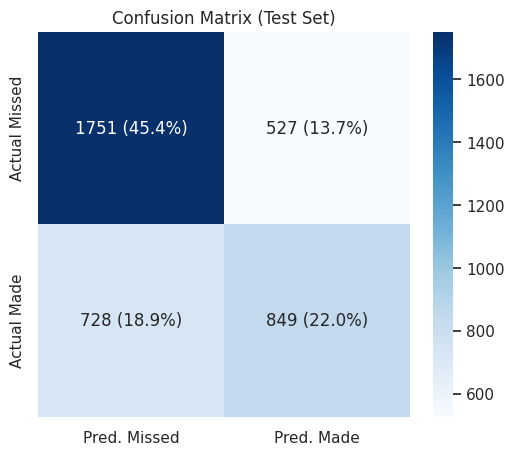


--- QUALITATIVE ERROR ANALYSIS ---
Total shots: 3855 | Total errors: 1255
Error Rate: 32.56%
Avg distance of Errors: 14.89 ft
Avg distance of Correct predictions: 15.16 ft


In [13]:
# This block performs the final test on unseen data and performs 
# quantitative and qualitative error diagnostics.

from sklearn.metrics import confusion_matrix

# 1. Final Predictions on Test Set
y_test_pred = best_rf_model.predict(X_test)
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]

# 2. Quantitative Metrics
print("--- FINAL EVALUATION ON TEST SET ---")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Final Test ROC AUC:  {roc_auc_score(y_test, y_test_proba):.4f}")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred, target_names=['Missed (0)', 'Made (1)']))

# 3. Visual Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=[[f"{v} ({v/cm.sum():.1%})" for v in row] for row in cm], fmt='', cmap='Blues', 
            xticklabels=['Pred. Missed', 'Pred. Made'], 
            yticklabels=['Actual Missed', 'Actual Made'])
plt.title("Confusion Matrix (Test Set)")
plt.show()

# 4. Qualitative Error Analysis
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['predicted'] = y_test_pred
errors = results_df[results_df['actual'] != results_df['predicted']]

print("\n--- QUALITATIVE ERROR ANALYSIS ---")
print(f"Total shots: {len(results_df)} | Total errors: {len(errors)}")
print(f"Error Rate: {len(errors)/len(results_df):.2%}")
print(f"Avg distance of Errors: {errors['shot_distance'].mean():.2f} ft")
print(f"Avg distance of Correct predictions: {results_df[results_df['actual'] == results_df['predicted']]['shot_distance'].mean():.2f} ft")

### Analysis of Results & Model Performance

The evaluation on the unseen Test Set (N=3855) confirms the robustness of the Random Forest model, yielding an **Accuracy of 67.44%** and a **ROC AUC of 0.6989**.

**Key Observations:**
1. **Recall Discrepancy:** The model shows a higher recall for the 'Missed' class (0.77) compared to the 'Made' class (0.54). This behavior is consistent with the nature of the dataset: since missing a shot is statistically more common and often more predictable based on spatial/mechanical features, the model is more conservative in predicting a successful outcome (Made).
2. **Error Pattern:** The qualitative analysis of errors reveals that the average distance of failed predictions (14.89 ft) is actually slightly lower than the average distance of correct ones (15.16 ft). This indicates that raw distance is no longer the primary driver of misclassifications. Both correct and incorrect predictions hover closely around the ~15 ft mark, confirming that the model struggles consistently in the "mid-range" zone. This area represents high tactical uncertainty in the NBA, where shot success heavily depends on defensive pressure and contests, which are variables not captured in the current dataset.
3. **Generalization:** The performance metrics are aligned between the Validation and Test sets, proving that the model has successfully generalized the underlying patterns without overfitting.